# regrouper les villes selon leur volume de candidatures

In [1]:
import pyodbc



# Replace these with your actual database credentials
server = 'LAPTOP-BJE2TQGI\KK'  # e.g., 'localhost' or '192.168.1.100'
database = 'add'  # e.g., 'SalesDB'


# Create a connection string
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database}'

# Try connecting to the databaseimport pyodbc

# Replace with your actual details
server = 'LAPTOP-BJE2TQGI\KK'
database = 'add'

# Use Trusted Connection (Windows login)
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    conn = pyodbc.connect(conn_str)
    print("✅ Connection successful!")

    cursor = conn.cursor()

    # Query to list all tables in the database
    cursor.execute("SELECT TABLE_NAME FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_TYPE='BASE TABLE'")

    print("📋 Tables in the database:")
    for row in cursor.fetchall():
        print("-", row.TABLE_NAME)

    conn.close()

except Exception as e:
    print("❌ Connection failed. Error:", e)

try:
    conn = pyodbc.connect(conn_str)
    print("Connection successful!")
    conn.close()  # Close the connection after testing
except Exception as e:
    print("Connection failed. Error:", e)

✅ Connection successful!
📋 Tables in the database:
- date
- Dim_bac
- Dim_Company
- Dim_Condidat
- Dim_condidature
- Dim_cursus
- Dim_date
- Dim_employer
- Dim_job
- Dim_parent
- Dim_region
- Dim_speciality
- Dim_University
- fact_a
- Fact_employbility
Connection successful!


# Clustering Kmeans

✅ Connexion réussie
📊 Données chargées avec succès
      ville_et  total_candidatures
0        Alger                   2
1        Gabès                  93
2  Constantine                   1
3        Tunis                  75
4       Annaba                   1


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\1370466108.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



🔍 Résultat du clustering :
       ville_et  total_candidatures  cluster
7       Manouba                1025        0
1         Gabès                  93        1
17       Nabeul                 108        1
3         Tunis                  75        1
16       Sousse                  97        1
5      Monastir                 114        1
15        Gafsa                  93        1
8        Ariana                 120        1
18      Bizerte                 116        1
14         Sfax                  98        1
13     Kairouan                  85        1
0         Alger                   2        2
9          2040                   1        2
11        Blida                   1        2
10       Bejaia                   1        2
6    Mostaganem                   1        2
4        Annaba                   1        2
2   Constantine                   1        2
12   Tizi-Ouzou                   1        2
19         Oran                   1        2


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\1370466108.py:72: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from current font.
  plt.tight_layout()  # Ajustement automatique des marges
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


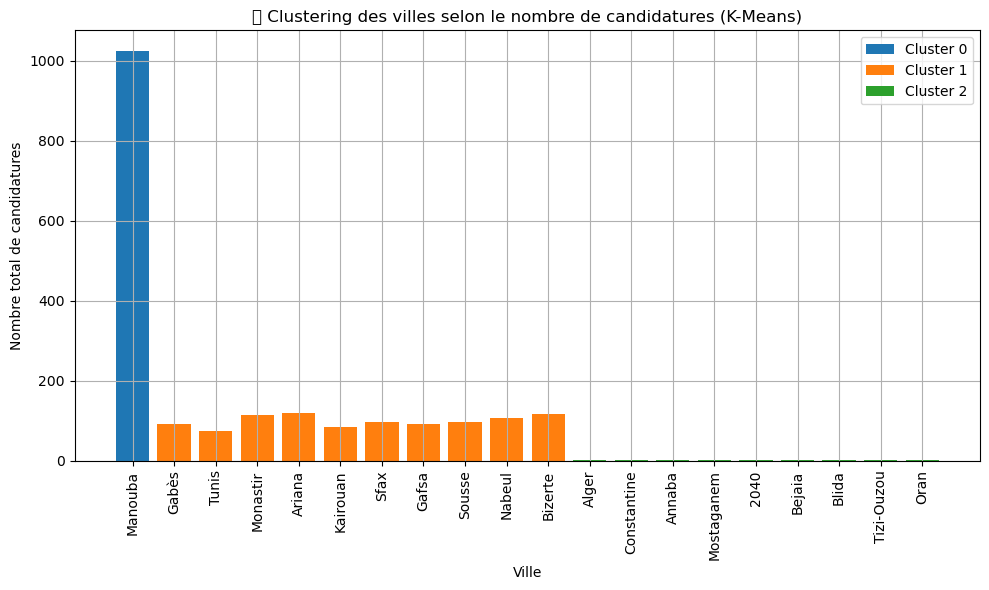

✅ Silhouette Score : 0.86


In [6]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation de données sous forme de DataFrame
import pyodbc  # Pour établir une connexion à une base de données SQL Server
from sklearn.cluster import KMeans  # Pour effectuer le clustering avec l'algorithme K-Means
from sklearn.preprocessing import StandardScaler  # Pour normaliser les données
from sklearn.metrics import silhouette_score  # Pour évaluer la qualité du clustering
import matplotlib.pyplot as plt  # Pour créer des graphiques

# Informations de connexion à la base de données SQL Server
server = 'LAPTOP-BJE2TQGI\KK'  # Nom du serveur
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'  
# Chaîne de connexion au format attendu par pyodbc avec authentification Windows

try:
    # Établir la connexion avec la base de données
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie")  # Message de confirmation

    # Requête SQL : calcul du nombre total de candidatures par ville
    query = """
    SELECT r.ville_et, COUNT(ca.condidature_id) AS total_candidatures
    FROM Dim_region r
    JOIN Dim_Condidat c ON r.id_et = c.id_et
    JOIN Dim_condidature ca ON c.id_et = ca.id_et
    WHERE r.ville_et IS NOT NULL
    GROUP BY r.ville_et
    """
    # La requête récupère chaque ville et le nombre total de candidatures associées

    # Exécution de la requête et chargement des résultats dans un DataFrame
    df = pd.read_sql(query, conn)

    # Fermeture de la connexion une fois les données récupérées
    conn.close()
    print("📊 Données chargées avec succès")  # Confirmation du chargement
    print(df.head())  # Affichage des premières lignes du DataFrame

    # Filtrage des villes avec au moins une candidature
    df = df[df['total_candidatures'] > 0]

    # Préparation des données pour le clustering : sélection de la colonne cible
    X = df[['total_candidatures']]  # On sélectionne uniquement la colonne d'intérêt

    # Normalisation des données (centrées réduites)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # Transformation standard (moyenne=0, écart-type=1)

    # Clustering avec l'algorithme K-Means (nombre de clusters fixé à 3)
    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)  # random_state pour reproductibilité
    df['cluster'] = kmeans.fit_predict(X_scaled)  # Création d'une nouvelle colonne "cluster"

    # Affichage du résultat du clustering, trié par numéro de cluster
    print("\n🔍 Résultat du clustering :")
    print(df.sort_values(by='cluster'))

    # Visualisation du résultat sous forme d’un diagramme en barres
    plt.figure(figsize=(10, 6))  # Taille du graphique
    for cluster in range(k):
        plt.bar(
            df[df['cluster'] == cluster]['ville_et'],  # X : noms des villes du cluster
            df[df['cluster'] == cluster]['total_candidatures'],  # Y : nombre de candidatures
            label=f'Cluster {cluster}'  # Légende pour chaque cluster
        )

    plt.xlabel("Ville")  # Label de l'axe des X
    plt.ylabel("Nombre total de candidatures")  # Label de l'axe des Y
    plt.title("🏙️ Clustering des villes selon le nombre de candidatures (K-Means)")  # Titre du graphique
    plt.xticks(rotation=90)  # Rotation des noms de villes pour lisibilité
    plt.legend()  # Affichage de la légende
    plt.tight_layout()  # Ajustement automatique des marges
    plt.grid(True)  # Grille sur le graphique
    plt.show()  # Affichage du graphique

    # Évaluation de la qualité du clustering avec le score de silhouette
    score = silhouette_score(X_scaled, df['cluster'])  # Calcul du score
    print(f"✅ Silhouette Score : {score:.2f}")  # Affichage du score (entre -1 et 1)

# En cas d'erreur lors de l'exécution
except Exception as e:
    print("❌ Erreur :", e)  # Affichage du message d’erreur


✅ Connexion réussie
📊 Données chargées avec succès
      ville_et  total_candidatures
0        Alger                   2
1        Gabès                  93
2  Constantine                   1
3        Tunis                  75
4       Annaba                   1


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\2243397408.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



🔍 Résultat du clustering :
       ville_et  total_candidatures  cluster
7       Manouba                1025        0
1         Gabès                  93        1
17       Nabeul                 108        1
3         Tunis                  75        1
16       Sousse                  97        1
5      Monastir                 114        1
15        Gafsa                  93        1
8        Ariana                 120        1
18      Bizerte                 116        1
14         Sfax                  98        1
13     Kairouan                  85        1
0         Alger                   2        2
9          2040                   1        2
11        Blida                   1        2
10       Bejaia                   1        2
6    Mostaganem                   1        2
4        Annaba                   1        2
2   Constantine                   1        2
12   Tizi-Ouzou                   1        2
19         Oran                   1        2


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\2243397408.py:84: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  plt.tight_layout()  # Ajustement automatique pour éviter le chevauchement
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128205 (\N{ROUND PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


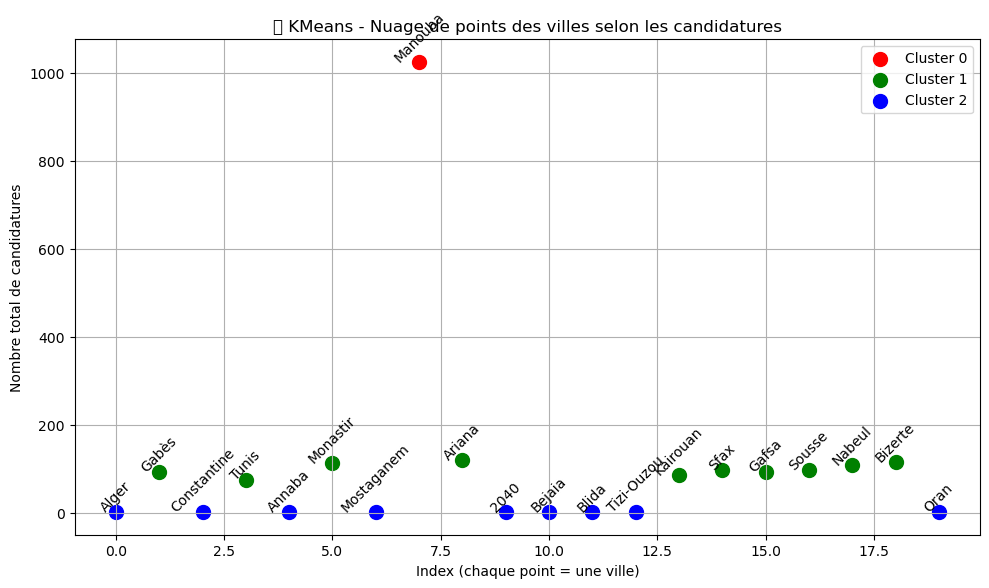

✅ Silhouette Score : 0.86


In [7]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation de données tabulaires (DataFrame)
import pyodbc  # Pour se connecter à une base de données SQL Server
from sklearn.cluster import KMeans  # Pour le clustering K-Means
from sklearn.preprocessing import StandardScaler  # Pour la normalisation des données
from sklearn.metrics import silhouette_score  # Pour évaluer la qualité du clustering
import matplotlib.pyplot as plt  # Pour créer des graphiques

# Informations de connexion à SQL Server
server = 'LAPTOP-BJE2TQGI\KK'  # Nom du serveur
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'
# Chaîne de connexion formatée pour SQL Server avec authentification Windows

try:
    # Connexion à la base de données
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie")

    # Requête SQL pour obtenir le nombre de candidatures par ville
    query = """
    SELECT r.ville_et, COUNT(ca.condidature_id) AS total_candidatures
    FROM Dim_region r
    JOIN Dim_Condidat c ON r.id_et = c.id_et
    JOIN Dim_condidature ca ON c.id_et = ca.id_et
    WHERE r.ville_et IS NOT NULL
    GROUP BY r.ville_et
    """
    # On récupère les villes (non nulles) et le nombre total de candidatures par ville

    # Exécution de la requête SQL et chargement des résultats dans un DataFrame pandas
    df = pd.read_sql(query, conn)

    # Fermeture de la connexion à la base de données après chargement des données
    conn.close()
    print("📊 Données chargées avec succès")
    print(df.head())  # Affichage des 5 premières lignes du DataFrame

    # Suppression des villes avec 0 candidature pour éviter les biais
    df = df[df['total_candidatures'] > 0]

    # Sélection des données à normaliser (ici, une seule variable)
    X = df[['total_candidatures']]

    # Normalisation des données pour que le clustering soit plus performant
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)  # Les données sont centrées-réduites

    # Application de l'algorithme KMeans avec 3 clusters
    k = 3
    kmeans = KMeans(n_clusters=k, random_state=42)  # random_state = pour reproductibilité
    df['cluster'] = kmeans.fit_predict(X_scaled)  # Ajout d'une colonne 'cluster' dans le DataFrame

    # Affichage du résultat du clustering, trié selon les clusters
    print("\n🔍 Résultat du clustering :")
    print(df.sort_values(by='cluster'))

    # Visualisation sous forme de scatter plot (nuage de points)
    plt.figure(figsize=(10, 6))  # Définition de la taille du graphique
    colors = ['red', 'green', 'blue']  # Couleurs pour chaque cluster

    # Affichage des points colorés selon leur cluster
    for cluster in range(k):
        clustered_data = df[df['cluster'] == cluster]  # Filtrage par cluster
        plt.scatter(
            clustered_data.index,  # Axe X : index (position dans le DataFrame)
            clustered_data['total_candidatures'],  # Axe Y : nombre de candidatures
            color=colors[cluster],  # Couleur selon cluster
            label=f'Cluster {cluster}',  # Légende
            s=100  # Taille des points
        )

    # Affichage des noms de villes au-dessus de chaque point du scatter plot
    for i in range(len(df)):
        plt.text(i, df['total_candidatures'].iloc[i] + 0.5, df['ville_et'].iloc[i],
                 rotation=45, ha='center')  # Nom de ville légèrement au-dessus du point

    # Personnalisation du graphique
    plt.xlabel("Index (chaque point = une ville)")
    plt.ylabel("Nombre total de candidatures")
    plt.title("📍 KMeans - Nuage de points des villes selon les candidatures")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()  # Ajustement automatique pour éviter le chevauchement
    plt.show()  # Affichage du graphique final

    # Calcul et affichage du score de silhouette pour évaluer la qualité du clustering
    score = silhouette_score(X_scaled, df['cluster'])
    print(f"✅ Silhouette Score : {score:.2f}")

# En cas d'erreur dans l'exécution du code (connexion, requête, clustering, etc.)
except Exception as e:
    print("❌ Erreur :", e)  # Affichage de l'erreur


# Clustering DBSCAN

✅ Connexion réussie
📊 Données chargées avec succès
      ville_et  total_candidatures
0        Alger                   2
1        Gabès                  93
2  Constantine                   1
3        Tunis                  75
4       Annaba                   1


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\4282813006.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\USER\AppData\Local\Temp\ipykernel_18812\4282813006.py:69: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()  # Optimisation de l'espace du graphique
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


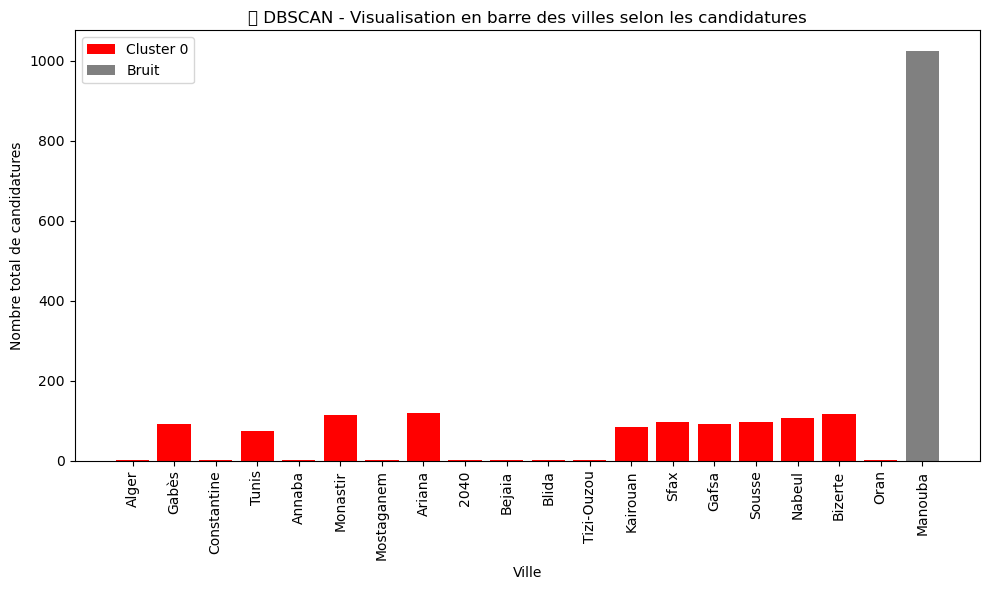

✅ Silhouette Score DBSCAN : 0.89


In [8]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation des données tabulaires
import pyodbc  # Pour la connexion à la base de données SQL Server
from sklearn.cluster import DBSCAN  # Pour le clustering basé sur la densité (DBSCAN)
from sklearn.preprocessing import StandardScaler  # Pour la normalisation des données
from sklearn.metrics import silhouette_score  # Pour évaluer la qualité du clustering
import matplotlib.pyplot as plt  # Pour tracer les graphiques

# Définition des paramètres de connexion à SQL Server
server = 'LAPTOP-BJE2TQGI\KK'  # Nom du serveur SQL
database = 'add'  # Nom de la base de données
# Chaîne de connexion complète pour SQL Server avec connexion Windows
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # Connexion à la base de données
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie")  # Message de succès si la connexion fonctionne

    # Définition de la requête SQL pour récupérer le nombre total de candidatures par ville
    query = """
    SELECT r.ville_et, COUNT(ca.condidature_id) AS total_candidatures
    FROM Dim_region r
    JOIN Dim_Condidat c ON r.id_et = c.id_et
    JOIN Dim_condidature ca ON c.id_et = ca.id_et
    WHERE r.ville_et IS NOT NULL
    GROUP BY r.ville_et
    """

    # Exécution de la requête et chargement des résultats dans un DataFrame pandas
    df = pd.read_sql(query, conn)
    conn.close()  # Fermeture de la connexion à la base de données
    print("📊 Données chargées avec succès")  # Message de confirmation
    print(df.head())  # Affichage des premières lignes du DataFrame

    # Nettoyage : suppression des villes ayant 0 candidature
    df = df[df['total_candidatures'] > 0]

    # Sélection de la colonne à utiliser pour le clustering
    X = df[['total_candidatures']]

    # Normalisation des données pour que DBSCAN fonctionne correctement
    scaler = StandardScaler()  # Création de l'objet StandardScaler
    X_scaled = scaler.fit_transform(X)  # Transformation des données

    # Application de l'algorithme DBSCAN avec les paramètres eps et min_samples
    dbscan = DBSCAN(eps=2, min_samples=3)  # Création du modèle DBSCAN
    df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)  # Attribution du cluster à chaque ville

    # Définition des couleurs pour chaque cluster (y compris le bruit -1)
    cluster_colors = {0: 'red', 1: 'green', 2: 'blue', -1: 'gray'}  # -1 correspond aux points considérés comme "bruit"

    # Création du graphique en barres
    plt.figure(figsize=(10, 6))  # Taille du graphique
    for cluster in df['cluster_dbscan'].unique():  # Boucle sur tous les clusters trouvés
        cluster_data = df[df['cluster_dbscan'] == cluster]  # Filtrage des données pour un cluster donné
        plt.bar(  # Création d'une barre pour chaque ville appartenant au cluster
            cluster_data['ville_et'],  # Noms des villes
            cluster_data['total_candidatures'],  # Nombre de candidatures
            color=cluster_colors.get(cluster, 'gray'),  # Couleur selon le cluster
            label=f'Cluster {cluster}' if cluster != -1 else 'Bruit'  # Légende
        )

    # Personnalisation du graphique
    plt.xlabel("Ville")  # Label de l'axe des X
    plt.ylabel("Nombre total de candidatures")  # Label de l'axe des Y
    plt.title("📊 DBSCAN - Visualisation en barre des villes selon les candidatures")  # Titre du graphique
    plt.xticks(rotation=90)  # Rotation des noms des villes pour une meilleure lisibilité
    plt.tight_layout()  # Optimisation de l'espace du graphique
    plt.legend()  # Affichage de la légende
    plt.show()  # Affichage du graphique

    # Évaluation du clustering avec le Silhouette Score (si au moins 2 clusters)
    if len(df['cluster_dbscan'].unique()) > 1:  # Vérifie qu'il y a plus d'un cluster
        score_dbscan = silhouette_score(X_scaled, df['cluster_dbscan'])  # Calcul du score de silhouette
        print(f"✅ Silhouette Score DBSCAN : {score_dbscan:.2f}")  # Affichage du score
    else:
        print("❌ Pas assez de clusters valides pour calculer le Silhouette Score")  # Message d'erreur si 1 seul cluster (ou que du bruit)

except Exception as e:
    print("❌ Erreur :", e)  # Gestion des erreurs éventuelles (ex : problème de connexion)


# Clustering GMM

✅ Connexion réussie
📊 Données chargées avec succès
      ville_et  total_candidatures
0        Alger                   2
1        Gabès                  93
2  Constantine                   1
3        Tunis                  75
4       Annaba                   1


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\642621524.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\AppData\Local\Temp\ipykernel_18812\642621524.py:68: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()  # Ajustement automatique de la mise en page
C:\Users\USER\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


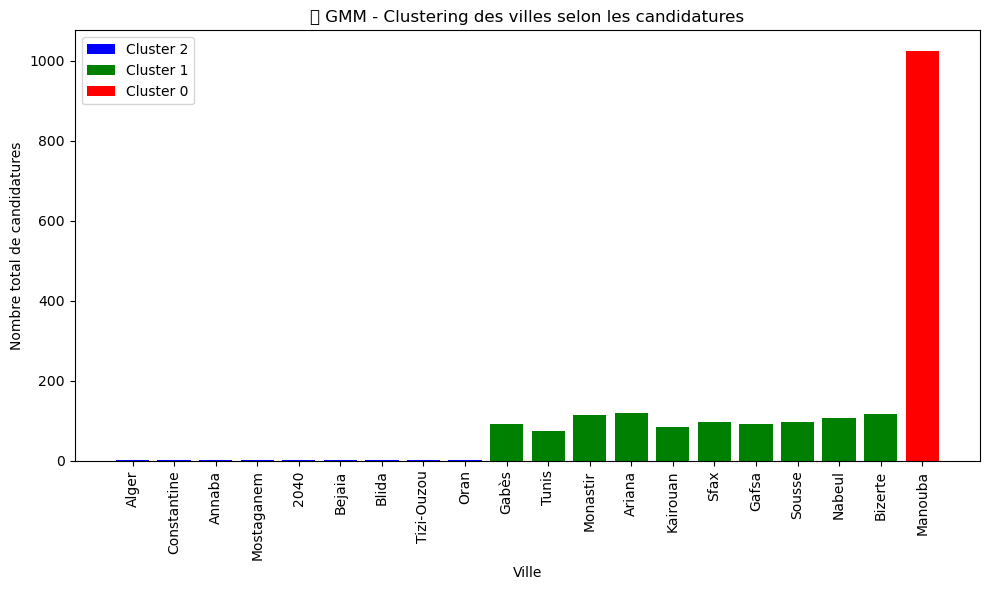

✅ Silhouette Score GMM : 0.86


In [9]:
# Importation des bibliothèques nécessaires
import pandas as pd  # Pour la manipulation des données sous forme de tableau
import pyodbc  # Pour établir une connexion avec une base de données SQL Server
from sklearn.mixture import GaussianMixture  # Pour appliquer le clustering via le modèle GMM (Gaussian Mixture Model)
from sklearn.preprocessing import StandardScaler  # Pour normaliser les données (mise à l'échelle)
from sklearn.metrics import silhouette_score  # Pour évaluer la qualité du clustering
import matplotlib.pyplot as plt  # Pour la visualisation graphique (tracé de graphiques)

# Définition des informations de connexion à SQL Server
server = 'LAPTOP-BJE2TQGI\KK'  # Nom du serveur SQL
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'  # Chaîne de connexion

try:
    # Connexion à la base de données
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie")  # Message de confirmation si la connexion est correcte

    # Requête SQL pour récupérer le nombre total de candidatures par ville
    query = """
    SELECT r.ville_et, COUNT(ca.condidature_id) AS total_candidatures
    FROM Dim_region r
    JOIN Dim_Condidat c ON r.id_et = c.id_et
    JOIN Dim_condidature ca ON c.id_et = ca.id_et
    WHERE r.ville_et IS NOT NULL
    GROUP BY r.ville_et
    """

    # Exécution de la requête et chargement des résultats dans un DataFrame
    df = pd.read_sql(query, conn)
    conn.close()  # Fermeture de la connexion après chargement des données
    print("📊 Données chargées avec succès")  # Message de confirmation
    print(df.head())  # Affichage des premières lignes du DataFrame

    # Filtrage : on retire les villes avec 0 candidatures (inutiles pour le clustering)
    df = df[df['total_candidatures'] > 0]

    # Sélection des données numériques pour le clustering
    X = df[['total_candidatures']]  # On ne garde que la colonne "total_candidatures"

    # Normalisation des données pour éviter les effets d’échelle
    scaler = StandardScaler()  # Création d’un objet pour la normalisation
    X_scaled = scaler.fit_transform(X)  # Application de la normalisation sur les données

    # Création et entraînement du modèle GMM avec 3 clusters
    gmm = GaussianMixture(n_components=3, random_state=42)  # Initialisation du modèle avec 3 composantes
    df['cluster_gmm'] = gmm.fit_predict(X_scaled)  # Application du clustering et ajout du résultat dans une nouvelle colonne

    # Définition des couleurs associées à chaque cluster (par défaut : 3 clusters)
    cluster_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple'}  # Palette de couleurs (au cas où il y ait 4 clusters)

    # Visualisation du résultat du clustering via un diagramme en barres
    plt.figure(figsize=(10, 6))  # Définition de la taille de la figure
    for cluster in df['cluster_gmm'].unique():  # Boucle sur chaque cluster identifié
        cluster_data = df[df['cluster_gmm'] == cluster]  # Filtrage des données du cluster courant
        plt.bar(  # Création d'une barre pour chaque ville du cluster
            cluster_data['ville_et'],  # Axe des X : noms des villes
            cluster_data['total_candidatures'],  # Axe des Y : nombre de candidatures
            color=cluster_colors.get(cluster, 'gray'),  # Couleur en fonction du cluster
            label=f'Cluster {cluster}'  # Légende correspondant au cluster
        )

    # Personnalisation du graphique
    plt.xlabel("Ville")  # Label de l’axe des X
    plt.ylabel("Nombre total de candidatures")  # Label de l’axe des Y
    plt.title("📊 GMM - Clustering des villes selon les candidatures")  # Titre du graphique
    plt.xticks(rotation=90)  # Rotation des étiquettes pour éviter le chevauchement
    plt.tight_layout()  # Ajustement automatique de la mise en page
    plt.legend()  # Affichage de la légende (clusters)
    plt.show()  # Affichage du graphique final

    # Évaluation du clustering avec le Silhouette Score
    score_gmm = silhouette_score(X_scaled, df['cluster_gmm'])  # Calcul du score de qualité du clustering
    print(f"✅ Silhouette Score GMM : {score_gmm:.2f}")  # Affichage du score (plus c’est proche de 1, mieux c’est)

# Bloc d'exception pour gérer les erreurs
except Exception as e:
    print("❌ Erreur :", e)  # Affichage du message d'erreur en cas d’échec (connexion, requête, etc.)


# Clustering comparaison entre 3 Algo

✅ Connexion réussie
📊 Données chargées avec succès
      ville_et  total_candidatures
0        Alger                   2
1        Gabès                  93
2  Constantine                   1
3        Tunis                  75
4       Annaba                   1


C:\Users\USER\AppData\Local\Temp\ipykernel_18812\3379319957.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows wi

✅ Silhouette Score KMeans : 0.86
✅ Silhouette Score DBSCAN : 0.89
✅ Silhouette Score GMM : 0.86


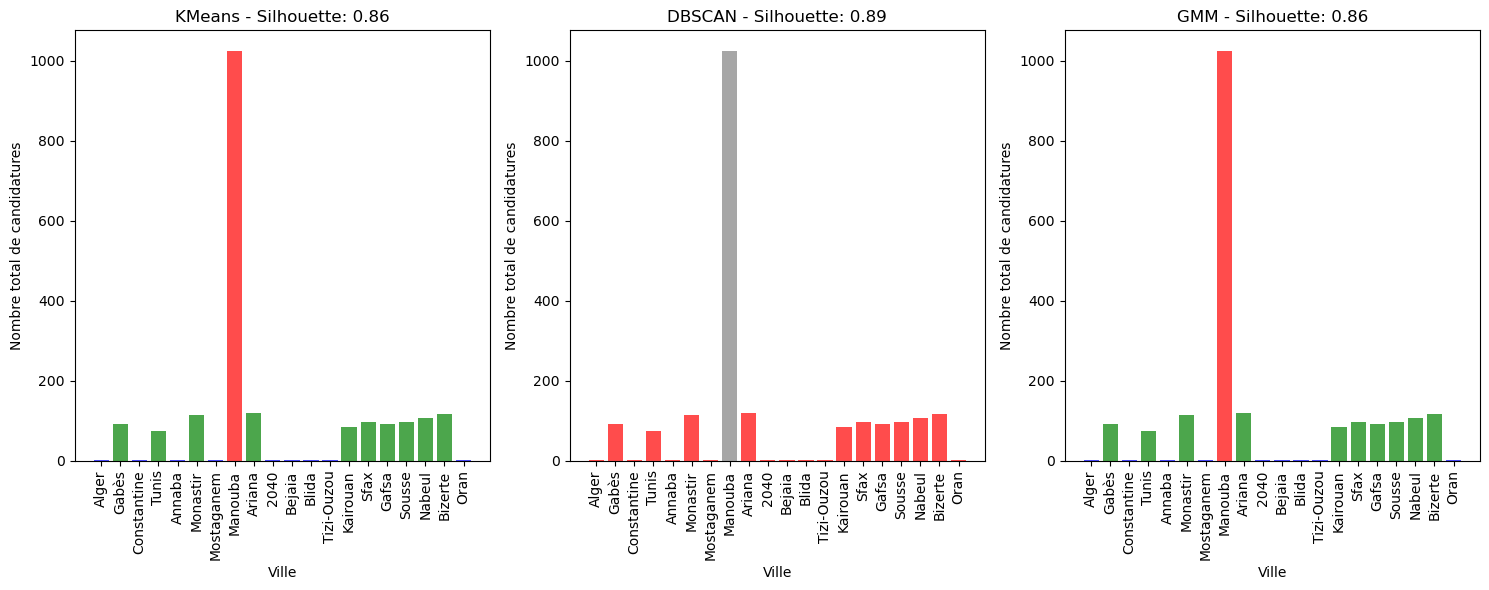

🎯 La meilleure méthode est : DBSCAN avec un Silhouette Score de 0.89


In [5]:
import pandas as pd
import pyodbc
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Connexion SQL Server
server = 'LAPTOP-BJE2TQGI\KK'
database = 'add'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

try:
    # Connexion
    conn = pyodbc.connect(conn_str)
    print("✅ Connexion réussie")

    # Requête SQL : nombre de candidatures par ville
    query = """
    SELECT r.ville_et, COUNT(ca.condidature_id) AS total_candidatures
    FROM Dim_region r
    JOIN Dim_Condidat c ON r.id_et = c.id_et
    JOIN Dim_condidature ca ON c.id_et = ca.id_et
    WHERE r.ville_et IS NOT NULL
    GROUP BY r.ville_et
    """

    df = pd.read_sql(query, conn)
    conn.close()
    print("📊 Données chargées avec succès")
    print(df.head())

    # Filtrage (au cas où certaines villes ont très peu de données)
    df = df[df['total_candidatures'] > 0]

    # Préparation des données
    X = df[['total_candidatures']]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Initialisation des modèles
    kmeans = KMeans(n_clusters=3, random_state=42)
    dbscan = DBSCAN(eps=2, min_samples=3)
    gmm = GaussianMixture(n_components=3, random_state=42)

    # Appliquer les modèles
    df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)
    df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)
    df['cluster_gmm'] = gmm.fit_predict(X_scaled)

    # Calcul des silhouette scores
    score_kmeans = silhouette_score(X_scaled, df['cluster_kmeans'])
    score_dbscan = silhouette_score(X_scaled, df['cluster_dbscan'])
    score_gmm = silhouette_score(X_scaled, df['cluster_gmm'])

    # Affichage des résultats des scores
    print(f"✅ Silhouette Score KMeans : {score_kmeans:.2f}")
    print(f"✅ Silhouette Score DBSCAN : {score_dbscan:.2f}")
    print(f"✅ Silhouette Score GMM : {score_gmm:.2f}")

    # Comparaison des silhouettes
    scores = {'KMeans': score_kmeans, 'DBSCAN': score_dbscan, 'GMM': score_gmm}

    # Visualisation des clusters et des scores
    plt.figure(figsize=(15, 6))

    # Définir les couleurs pour chaque cluster
    cluster_colors = ['red', 'green', 'blue']

    # Visualisation KMeans
    plt.subplot(1, 3, 1)
    plt.bar(df['ville_et'], df['total_candidatures'], color=[cluster_colors[i] for i in df['cluster_kmeans'] % 3], alpha=0.7)
    plt.xlabel("Ville")
    plt.ylabel("Nombre total de candidatures")
    plt.title(f"KMeans - Silhouette: {score_kmeans:.2f}")
    plt.xticks(rotation=90)

    # Visualisation DBSCAN
    plt.subplot(1, 3, 2)
    plt.bar(df['ville_et'], df['total_candidatures'], color=[cluster_colors[i % 3] if i != -1 else 'gray' for i in df['cluster_dbscan']], alpha=0.7)
    plt.xlabel("Ville")
    plt.ylabel("Nombre total de candidatures")
    plt.title(f"DBSCAN - Silhouette: {score_dbscan:.2f}")
    plt.xticks(rotation=90)

    # Visualisation GMM
    plt.subplot(1, 3, 3)
    plt.bar(df['ville_et'], df['total_candidatures'], color=[cluster_colors[i] for i in df['cluster_gmm'] % 3], alpha=0.7)
    plt.xlabel("Ville")
    plt.ylabel("Nombre total de candidatures")
    plt.title(f"GMM - Silhouette: {score_gmm:.2f}")
    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

    # Comparaison des méthodes
    best_method = max(scores, key=scores.get)
    print(f"🎯 La meilleure méthode est : {best_method} avec un Silhouette Score de {scores[best_method]:.2f}")

except Exception as e:
    print("❌ Erreur :", e)
